### SVM ( 서포트벡터머신 )
- 패턴 인식, 자료 분석등을 위한 지도학습 모델
- 회귀, 분류 모두 존재
- 회귀선에서 일정양 만큼 떨어진 부분에 영역을 생성하여 영역 안과 밖의 데이터들의 가중치를 변화

- parameter
    - C
        - 기본값 : 1.0
        - 규제 강도의 역수
        - 마진(margin) 영역의 크기
    - kernel (커널 함수의 종류)
        - 기본값 : 'rbf'
        - 실제의 데이터가 선형이 아닌 경우 커널 함수를 이용하여 데이터를 고차원 공간으로 매핑하여 직선으로 구분
        - 'linear' : 선형 SVM
        - 'poly' : 다항식 커널
        - 'rbf' : 가우시안 커널(가장 많이 사용)
    - gamma
        - 커널의 개수
        - linear가 아닌 경우라면 사용
        - gamma가 크다면 경계가 복잡해짐(과적합 위험)
        - 작다면 경계가 유연해짐(일반화 위험)
    - degree
        - 기본값 : 3
        - 다항식 커널에서의 차수
    - probability
        - 기본값 : False
        - 확률을 출력할것인가? -> True인 경우에는 predict_proba() 사용이 가능
        - True로 설정 시 추가적인 계산으로 인해 속도가 느려질 수 있음
    
- 속성
    - support_
        - 서포트 벡터 경계선에 딱 붙어있는 데이터의 인덱스의 갑
    - support_vector_
        - support_는 위치의 값이라면 그 값에 해당하는 실제 데이터의 값
    - n_support_
        - 클래스(컬럼)별 서포트 벡터의 개수
    - coef_
        - 결정 계수 (linear 사용 가능)

- 메서드
    - decision_function()
        - 결정 함수의 값(margin과의 거리)
    

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


In [2]:
df = pd.read_csv('../data/classification.csv')
df.head()

,age,interest,success
0,23.657801,18.859917,0.0
1,22.573729,17.969223,0.0
2,32.553424,29.463651,0.0
3,6.718035,25.704665,1.0
4,14.401919,16.770856,0.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       297 non-null    float64
 1   interest  297 non-null    float64
 2   success   297 non-null    float64
dtypes: float64(3)
memory usage: 7.1 KB


c:\Users\lovek\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\lovek\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\lovek\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.g

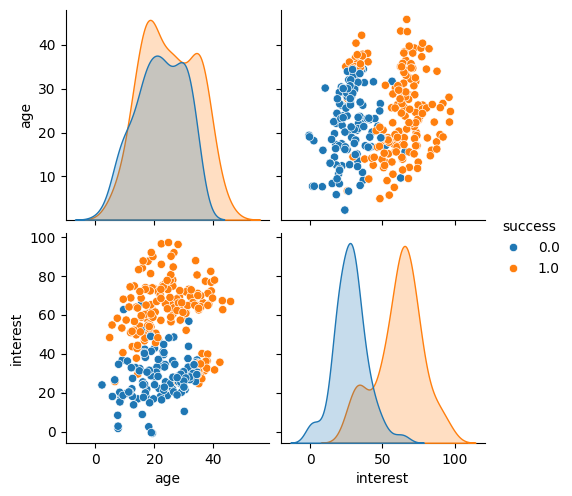

In [4]:
# 데이터 클래스 분포를 그래프로 확인
sns.pairplot(
    data = df,
    hue = 'success'
)

In [5]:
x = df.drop('success', axis = 1)
y = df['success']

X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, stratify=y, random_state=42
)

In [6]:
df['success'].value_counts()

success
1.0    169
0.0    128
Name: count, dtype: int64

In [7]:
svc = SVC()
svc2 = SVC(C=0.5)

In [8]:
svc.fit(X_train, y_train)
svc2.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",0.5
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [9]:
pred = svc.predict(X_test)
pred2 = svc2.predict(X_test)

In [10]:
acc = accuracy_score(y_test, pred)
acc_2 = accuracy_score(y_test, pred2)
prc = precision_score(y_test, pred)
prc_2 = precision_score(y_test, pred2)
rcll = recall_score(y_test, pred)
rcll_2 = recall_score(y_test, pred2)
f1 = f1_score(y_test, pred)
f1_2 = f1_score(y_test, pred2)

In [11]:
print('정확도 : ', round(acc, 2), round(acc_2, 2))
print('정밀도 : ', round(prc, 2), round(prc_2, 2))
print('재현율 : ', round(rcll, 2), round(rcll_2, 2))
print('f1 : ', round(f1, 2), round(f1_2, 2))


정확도 :  0.88 0.87
정밀도 :  0.93 0.93
재현율 :  0.84 0.82
f1 :  0.89 0.88


In [12]:
# 분류 분석 선형 SVC 모델을 로드
from sklearn.svm import LinearSVC

In [13]:
X_train

,age,interest
186,22.037690,70.170483
236,18.308514,54.004888
161,31.452201,33.088326
33,17.891597,87.565843
151,8.395444,15.224779
...,...,...
291,13.027910,13.735581
180,14.980555,31.206160
60,18.835070,65.171098
207,40.373123,31.696806


In [14]:
# # 마진 영역을 그래프로 표시
# plt.figure(figsize=(16,8))

# for i, c in enumerate([0.1, 100]):
#     # i -> 리스트의 위치(index) 값
#     # c -> 리스트의 원소의 값
#     # print(i)
#     # print(c)

#     model = LinearSVC(C = c, random_state=42)

#     model.fit(X_train, y_train)

#     # 경계선과의 거리를 확인
#     decision = model.decision_function(X_train)
    
#     # -1과 1사이의 값이 경계선 안쪽에 데이터
#     support_vector_indices = np.where(
#         np.abs(decision) <= 1 + 1e-15
#     )[0]
#     support_vector = X_train.values[support_vector_indices]

#     print(f' C의 값이 {c}인 경우 support_vector의 개수는 {len(support_vector)} ')

#     plt.subplot(1, 2, i+1)

#     plt.scatter(X_train.iloc[:, 0], X_train.iloc[:,1], c= y_train.values)

#     # 현재 좌표의 데이터들을 로드
#     ax = plt.gca()
#     xlim = ax.get_xlim()
#     ylim = ax.get_ylim()

#     # 격자 추가
#     xx, yy = np.meshgrid(
#         np.linspace(xlim[0], xlim[1], 50),
#         np.linspace(ylim[0], ylim[1], 50)
#     )

#     z = model.decision_function(np.c_[xx.ravel(), yy.ravel()])
#     z= z.reshape(xx.shape)

#     # 등고선 추가
#     plt.contour(
#         xx, yy, color='Black', levels = [-1,0,1], alpha = 0.5, linestyle = []
#     )

# 수정작업 필요

### SVR (서포트 벡터 머신 - 회귀)
- 입실론 튜브 안에 데이터들을 오차로 보지 않는다.
- 튜브 밖에 데이터에만 패널티를 부여

- parameter
    - kernel
        - linear
            - 사용이 가능 매개변수 : C, epsilron
        - rbf
            - 사용이 가능 매개변수 : C, epsilron, gamma
        - poly
            - 사용이 가능 매개변수 : C, epsilron, gamma, degree
    - epsilron
        - 오차 허용의 폭
    - max_iter
        - 기본값 : None
        - 최적화가 될때까지 최대 반복 횟수 ( 수치가 불안정한 경우 필요 - svm 모델에서는 시간이 오래 걸리 때문에 가급적이면 사용 )
    - tol
        - 기본값 : 0.001
        - 수렴의 판단 기준
- 속성
    - dual_coef_
        - 쌍대 문제의 알파 값들
    - coef_
        - 회귀 계수

In [15]:
from sklearn.svm import SVR

In [16]:
boston = pd.read_csv('../csv/boston.csv')

In [17]:
from sklearn.metrics import mean_squared_error, r2_score

In [18]:
x = boston.drop('Price',axis=1)
y = boston['Price']

In [19]:
# train, test 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=42, stratify=x['CHAS']
)

In [20]:
boston['CHAS'].value_counts()

CHAS
0.0    471
1.0     35
Name: count, dtype: int64

In [21]:
svr_rbf = SVR(kernel = 'rbf', gamma = 'auto', epsilon=0.1)
svr_lin = SVR(kernel = 'linear')
svr_poly = SVR(kernel='poly', gamma = 'auto')

In [22]:
# svr_lin.fit(X_train, y_train)
# svr_poly.fit(X_train, y_train)
# svr_rbf.fit(X_train, y_train)

In [23]:
# 랜덤 데이터를 생성
x = np.sort(
    5 * np.random.rand(40,1), axis = 0
)
x

array([[0.0401072 ],
       [0.08266943],
       [0.13981801],
       [0.44628011],
       [0.70216384],
       [0.91505609],
       [1.17174947],
       [1.69665496],
       [1.94464187],
       [1.97302021],
       [2.0208347 ],
       [2.07977455],
       [2.24014749],
       [2.3622346 ],
       [2.42390955],
       [2.83756574],
       [2.95221266],
       [3.04486739],
       [3.08098684],
       [3.09359863],
       [3.10392099],
       [3.2181108 ],
       [3.33755349],
       [3.57946826],
       [3.59503042],
       [3.67445867],
       [3.72236006],
       [3.80797918],
       [3.81406796],
       [3.86828672],
       [3.9420222 ],
       [3.96370479],
       [4.02048146],
       [4.16808886],
       [4.19632579],
       [4.26232668],
       [4.27353151],
       [4.31505299],
       [4.35778717],
       [4.75624759]])

In [24]:
y = np.sin(x)
y

array([[ 0.04009644],
       [ 0.0825753 ],
       [ 0.1393629 ],
       [ 0.43161297],
       [ 0.64587117],
       [ 0.79259679],
       [ 0.92143175],
       [ 0.99209025],
       [ 0.93092985],
       [ 0.9201927 ],
       [ 0.90043041],
       [ 0.87324286],
       [ 0.78422442],
       [ 0.70282291],
       [ 0.65764105],
       [ 0.29936486],
       [ 0.18825001],
       [ 0.09657451],
       [ 0.06056872],
       [ 0.0479756 ],
       [ 0.03766275],
       [-0.0764435 ],
       [-0.19470907],
       [-0.42401646],
       [-0.43805848],
       [-0.50800408],
       [-0.54866568],
       [-0.61814962],
       [-0.62292428],
       [-0.6644025 ],
       [-0.71765529],
       [-0.73258514],
       [-0.7700304 ],
       [-0.85548991],
       [-0.86976857],
       [-0.90042   ],
       [-0.90523772],
       [-0.92209514],
       [-0.93778482],
       [-0.99903837]])

In [25]:
len(y)

40

In [28]:
# 종속 변수 y에 노이즈 추가
y[::5] += 3 * (0.5 - np.random.rand(len(y[::5]), 1))

In [29]:
y

array([[ 1.52027118],
       [ 0.0825753 ],
       [ 0.1393629 ],
       [ 0.43161297],
       [ 0.64587117],
       [ 0.11519876],
       [ 0.92143175],
       [ 0.99209025],
       [ 0.93092985],
       [ 0.9201927 ],
       [-0.52591986],
       [ 0.87324286],
       [ 0.78422442],
       [ 0.70282291],
       [ 0.65764105],
       [ 0.22643997],
       [ 0.18825001],
       [ 0.09657451],
       [ 0.06056872],
       [ 0.0479756 ],
       [-1.08032559],
       [-0.0764435 ],
       [-0.19470907],
       [-0.42401646],
       [-0.43805848],
       [-0.54126862],
       [-0.54866568],
       [-0.61814962],
       [-0.62292428],
       [-0.6644025 ],
       [-1.06651427],
       [-0.73258514],
       [-0.7700304 ],
       [-0.85548991],
       [-0.86976857],
       [ 0.46602179],
       [-0.90523772],
       [-0.92209514],
       [-0.93778482],
       [-0.99903837]])

In [30]:
svr_lin.fit(x, y)
svr_rbf.fit(x, y)
svr_poly.fit(x, y)

c:\Users\lovek\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\lovek\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\lovek\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'poly'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'auto'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [32]:
boston.shape

(506, 14)

In [33]:
pred_lin = svr_lin.predict(x)
pred_rbf = svr_rbf.predict(x)
pred_poly = svr_poly.predict(x)

In [34]:
index = ['RBF','Linear','Poly']
cols = ['MSE','R2']

result = pd.DataFrame(index = index, columns = cols)
result

,MSE,R2
RBF,NaN,NaN
Linear,NaN,NaN
Poly,NaN,NaN


In [36]:
# 모델들을 리스트 생성
preds = [pred_rbf, pred_lin, pred_poly]

for pred, idx in zip(preds, index):
    mse = mean_squared_error(y, pred)
    r2 = r2_score(y, pred)

    result.loc[idx, 'MSE'] = round(mse,2)
    result.loc[idx, 'R2'] = round(r2 * 100, 2)

result

,MSE,R2
RBF,0.17,65.38
Linear,0.26,47.97
Poly,0.2,60.7
